# 🎥 Avenue Dataset — Abnormal Event Detection
## Pipeline: MobileNet (Feature Extraction) → LSTM (Sequence Modeling) → Sigmoid (Anomaly Probability)

**Architecture Overview:**
- **MobileNetV2** extracts spatial features per frame (frozen ImageNet weights)
- **LSTM** models temporal dependencies across frame sequences
- **Sigmoid** outputs probability [0, 1] per frame
- Frames with probability **> threshold** → **Abnormal**
- Frames with probability **≤ threshold** → **Normal**

---
## Cell 1 — Install & Import Libraries

In [1]:
# Install required packages (run once)
!pip install tensorflow opencv-python matplotlib scikit-learn tqdm numpy pandas seaborn


Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, TimeDistributed,
    GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, accuracy_score
)
from sklearn.model_selection import train_test_split

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"OpenCV version     : {cv2.__version__}")
print(f"GPU Available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.18.0
OpenCV version     : 4.10.0
GPU Available      : []


---
## Cell 2 — Configuration & Paths

In [3]:
# ============================================================
#  CONFIGURATION — Edit paths if needed
# ============================================================

# ---- Dataset Paths ----
BASE_DIR        = r"C:\Users\awati\Avenue_Dataset 3\Avenue Dataset"
TRAIN_VIDEO_DIR = os.path.join(BASE_DIR, "training_videos")
TEST_VIDEO_DIR  = os.path.join(BASE_DIR, "testing_videos")

# ---- Frame Extraction ----
IMG_HEIGHT    = 224          # MobileNetV2 input height
IMG_WIDTH     = 224          # MobileNetV2 input width
FRAME_SKIP    = 5            # Extract every N-th frame (reduce compute)

# ---- Sequence (LSTM) ----
SEQ_LENGTH    = 16           # Number of consecutive frames per sequence
STEP_SIZE     = 8            # Sliding window step

# ---- Training ----
BATCH_SIZE    = 8
EPOCHS        = 30
LEARNING_RATE = 1e-4
VAL_SPLIT     = 0.15

# ---- Inference ----
THRESHOLD     = 0.5          # Probability threshold: >0.5 => Abnormal

# ---- Feature Cache (speeds up re-runs) ----
CACHE_DIR     = os.path.join(BASE_DIR, "feature_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

# ---- Model Save ----
MODEL_PATH    = os.path.join(BASE_DIR, "mobilenet_lstm_abnormal.keras")

# ---- Verify paths ----
for name, path in [("Base", BASE_DIR), ("Train", TRAIN_VIDEO_DIR), ("Test", TEST_VIDEO_DIR)]:
    exists = os.path.exists(path)
    status = "✅ Found" if exists else "❌ NOT FOUND"
    print(f"{status}  [{name}]  {path}")

train_videos = sorted([f for f in os.listdir(TRAIN_VIDEO_DIR) if f.endswith(('.avi', '.mp4', '.AVI', '.MP4'))])
test_videos  = sorted([f for f in os.listdir(TEST_VIDEO_DIR)  if f.endswith(('.avi', '.mp4', '.AVI', '.MP4'))])

print(f"\nTraining videos  : {len(train_videos)}")
print(f"Testing  videos  : {len(test_videos)}")
print(f"\nTraining video list  : {train_videos}")
print(f"Testing  video list  : {test_videos}")

✅ Found  [Base]  C:\Users\awati\Avenue_Dataset 3\Avenue Dataset
✅ Found  [Train]  C:\Users\awati\Avenue_Dataset 3\Avenue Dataset\training_videos
✅ Found  [Test]  C:\Users\awati\Avenue_Dataset 3\Avenue Dataset\testing_videos

Training videos  : 16
Testing  videos  : 21

Training video list  : ['01.avi', '02.avi', '03.avi', '04.avi', '05.avi', '06.avi', '07.avi', '08.avi', '09.avi', '10.avi', '11.avi', '12.avi', '13.avi', '14.avi', '15.avi', '16.avi']
Testing  video list  : ['01.avi', '02.avi', '03.avi', '04.avi', '05.avi', '06.avi', '07.avi', '08.avi', '09.avi', '10.avi', '11.avi', '12.avi', '13.avi', '14.avi', '15.avi', '16.avi', '17.avi', '18.avi', '19.avi', '20.avi', '21.avi']


---
## Cell 3 — Utility: Frame Extraction from Video

In [4]:
def extract_frames(video_path, frame_skip=FRAME_SKIP, img_size=(IMG_HEIGHT, IMG_WIDTH)):
    """
    Extract frames from a video file.
    Returns: list of RGB frames (H, W, 3) as float32 in [0,255]
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_idx = 0

    if not cap.isOpened():
        print(f"  ⚠️  Cannot open: {video_path}")
        return frames

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_skip == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, img_size)
            frames.append(frame_resized.astype(np.float32))
        frame_idx += 1

    cap.release()
    return frames, total_frames, fps


def frames_to_sequences(frames, seq_length=SEQ_LENGTH, step=STEP_SIZE):
    """
    Convert list of frames into overlapping sequences using sliding window.
    Returns: np.array of shape (num_sequences, seq_length, H, W, 3)
    """
    sequences = []
    for start in range(0, len(frames) - seq_length + 1, step):
        seq = frames[start : start + seq_length]
        sequences.append(seq)
    return np.array(sequences, dtype=np.float32)


# Quick test
sample_path = os.path.join(TRAIN_VIDEO_DIR, train_videos[0])
sample_frames, tot, fps = extract_frames(sample_path, frame_skip=FRAME_SKIP)
sample_seqs = frames_to_sequences(sample_frames)

print(f"Sample video      : {train_videos[0]}")
print(f"Total raw frames  : {tot}  |  FPS: {fps:.1f}")
print(f"Extracted frames  : {len(sample_frames)}  (every {FRAME_SKIP} frames)")
print(f"Sequences shape   : {sample_seqs.shape}  → (num_seq, {SEQ_LENGTH}, {IMG_HEIGHT}, {IMG_WIDTH}, 3)")

Sample video      : 01.avi
Total raw frames  : 1364  |  FPS: 25.0
Extracted frames  : 273  (every 5 frames)
Sequences shape   : (33, 16, 224, 224, 3)  → (num_seq, 16, 224, 224, 3)


---
## Cell 4 — Build MobileNetV2 Feature Extractor

In [5]:
def build_mobilenet_extractor(img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    """
    Load MobileNetV2 (ImageNet weights), remove top classification layer.
    Returns spatial feature maps for each frame.
    Output shape: (batch, 1280) after GlobalAveragePooling2D
    """
    base_model = MobileNetV2(
        input_shape=(img_height, img_width, 3),
        include_top=False,           # Remove softmax classifier
        weights='imagenet'           # Pretrained features
    )
    base_model.trainable = False     # Freeze all layers — use as fixed extractor

    inputs = Input(shape=(img_height, img_width, 3))
    x = preprocess_input(inputs)    # MobileNetV2-specific normalization [-1, 1]
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)  # (batch, 7, 7, 1280) → (batch, 1280)

    extractor = Model(inputs, x, name="MobileNetV2_Extractor")
    return extractor


mobilenet_extractor = build_mobilenet_extractor()
mobilenet_extractor.summary()

print(f"\n✅ Feature vector size per frame: {mobilenet_extractor.output_shape[-1]}")

Model: "MobileNetV2_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ Feature vector size per frame: 1280


---
## Cell 5 — Extract & Cache MobileNet Features for All Videos

In [6]:
def extract_mobilenet_features_from_video(video_path, extractor, batch_size=32):
    """
    Extract per-frame MobileNet features from a video.
    Returns: np.array shape (num_frames, 1280)
    """
    frames, _, _ = extract_frames(video_path)
    if len(frames) == 0:
        return np.array([])

    all_features = []
    for i in range(0, len(frames), batch_size):
        batch = np.array(frames[i:i+batch_size])
        feats = extractor.predict(batch, verbose=0)
        all_features.append(feats)

    return np.vstack(all_features)  # (num_frames, 1280)


def get_or_cache_features(video_path, extractor, cache_dir=CACHE_DIR):
    """
    Load cached features if available, otherwise extract & save.
    """
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    cache_path = os.path.join(cache_dir, f"{video_name}_features.npy")

    if os.path.exists(cache_path):
        return np.load(cache_path)

    features = extract_mobilenet_features_from_video(video_path, extractor)
    if len(features) > 0:
        np.save(cache_path, features)
    return features


# ---- Extract features from ALL training videos (label = 0 → Normal) ----
print("=" * 60)
print("  Extracting MobileNet features from TRAINING videos...")
print("=" * 60)

train_features_all = []
train_labels_all   = []
train_video_map    = []   # (video_name, seq_idx) for traceability

for vname in tqdm(train_videos, desc="Training"):
    vpath = os.path.join(TRAIN_VIDEO_DIR, vname)
    feats = get_or_cache_features(vpath, mobilenet_extractor)  # (N, 1280)

    # Build sequences
    seqs = []
    for start in range(0, len(feats) - SEQ_LENGTH + 1, STEP_SIZE):
        seqs.append(feats[start:start+SEQ_LENGTH])
        train_video_map.append((vname, start))

    if len(seqs) > 0:
        seqs_arr = np.array(seqs)           # (num_seq, SEQ_LENGTH, 1280)
        train_features_all.append(seqs_arr)
        train_labels_all.extend([0] * len(seqs))   # Training = all Normal

X_train_raw = np.vstack(train_features_all)        # (total_seq, SEQ_LENGTH, 1280)
y_train_raw = np.array(train_labels_all)           # all zeros (Normal)

print(f"\n✅ Training sequences : {X_train_raw.shape}")
print(f"   Labels             : {np.unique(y_train_raw, return_counts=True)}")

  Extracting MobileNet features from TRAINING videos...


Training: 100%|████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 431.39it/s]


✅ Training sequences : (359, 16, 1280)
   Labels             : (array([0]), array([359], dtype=int64))


---
## Cell 6 — Prepare Training Labels (Normal=0 / Abnormal=1)

> Since training videos contain **only normal** events, we use a **self-supervised** approach:  
> We train the LSTM as a **binary classifier** on training normals and synthetically augment with simulated abnormal samples to teach the sigmoid boundary.

In [7]:
# =========================================================
#  Strategy: Use Normal training data + create synthetic
#  abnormal samples by adding Gaussian noise perturbations
#  This teaches the sigmoid output boundary.
#  At test time, truly abnormal frames produce high prob.
# =========================================================

def create_synthetic_abnormal(normal_seqs, noise_factor=2.5, n_samples=None):
    """
    Create pseudo-abnormal sequences by:
    1. Large Gaussian noise injection
    2. Random temporal shuffling (break temporal coherence)
    3. Feature magnitude scaling
    """
    if n_samples is None:
        n_samples = len(normal_seqs)

    indices  = np.random.choice(len(normal_seqs), n_samples, replace=(n_samples > len(normal_seqs)))
    abnormal = normal_seqs[indices].copy()

    # Method 1: Heavy noise
    noise = np.random.normal(0, noise_factor * abnormal.std(), abnormal.shape)
    abnormal += noise

    # Method 2: Temporal shuffle (break motion patterns)
    for i in range(len(abnormal)):
        perm = np.random.permutation(SEQ_LENGTH)
        abnormal[i] = abnormal[i][perm]

    return abnormal


# Build balanced dataset
n_normal   = len(X_train_raw)
X_abnormal = create_synthetic_abnormal(X_train_raw, noise_factor=2.5, n_samples=n_normal)
y_abnormal = np.ones(n_normal, dtype=np.float32)
y_normal   = np.zeros(n_normal, dtype=np.float32)

X_all = np.vstack([X_train_raw, X_abnormal])   # (2N, SEQ_LENGTH, 1280)
y_all = np.hstack([y_normal, y_abnormal])       # (2N,)

# Shuffle
shuffle_idx = np.random.permutation(len(X_all))
X_all = X_all[shuffle_idx]
y_all = y_all[shuffle_idx]

# Train / Validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=VAL_SPLIT, random_state=42, stratify=y_all
)

print(f"Training   set  : {X_tr.shape}  labels: {np.unique(y_tr, return_counts=True)}")
print(f"Validation set  : {X_val.shape}  labels: {np.unique(y_val, return_counts=True)}")
print(f"Feature dim/frame: {X_tr.shape[-1]}")

Training   set  : (610, 16, 1280)  labels: (array([0., 1.], dtype=float32), array([305, 305], dtype=int64))
Validation set  : (108, 16, 1280)  labels: (array([0., 1.], dtype=float32), array([54, 54], dtype=int64))
Feature dim/frame: 1280


---
## Cell 7 — Build LSTM + Sigmoid Model

In [8]:
def build_lstm_model(seq_length=SEQ_LENGTH, feature_dim=1280, lr=LEARNING_RATE):
    """
    LSTM model that takes MobileNet feature sequences and outputs
    anomaly probability via Sigmoid activation.

    Architecture:
      Input (SEQ_LENGTH, 1280)
        → LSTM(256, return_sequences=True)
        → Dropout(0.4)
        → LSTM(128, return_sequences=False)
        → Dropout(0.3)
        → Dense(64, relu)
        → BatchNorm
        → Dense(1, sigmoid)  ← outputs P(abnormal | sequence)
    """
    inputs = Input(shape=(seq_length, feature_dim), name="feature_sequence")

    # ---- LSTM Layer 1 (return all hidden states for richer context) ----
    x = LSTM(256, return_sequences=True,
             dropout=0.3, recurrent_dropout=0.2,
             name="lstm_1")(inputs)
    x = Dropout(0.4, name="drop_1")(x)

    # ---- LSTM Layer 2 (final hidden state only) ----
    x = LSTM(128, return_sequences=False,
             dropout=0.2, recurrent_dropout=0.2,
             name="lstm_2")(x)
    x = Dropout(0.3, name="drop_2")(x)

    # ---- Dense classifier ----
    x = Dense(64, activation='relu', name="dense_64")(x)
    x = BatchNormalization(name="batch_norm")(x)
    x = Dropout(0.2, name="drop_3")(x)

    # ---- Sigmoid output — P(frame sequence is Abnormal) ----
    outputs = Dense(1, activation='sigmoid', name="anomaly_probability")(x)

    model = Model(inputs, outputs, name="MobileNet_LSTM_AnomalyDetector")

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


lstm_model = build_lstm_model()
lstm_model.summary()

print("\n✅ Model built. Output = Sigmoid probability [0, 1]")
print(f"   Threshold = {THRESHOLD}  →  prob > {THRESHOLD} = ABNORMAL")

Model: "MobileNet_LSTM_AnomalyDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ feature_sequence (InputLayer)        │ (None, 16, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 16, 256)             │       1,573,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_1 (Dropout)                     │ (None, 16, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 128)                 │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_2 (Dropout)                     │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_norm (BatchNormalization)      │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_3 (Dropout)                     │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ anomaly_probability (Dense)          │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,779,585 (6.79 MB)

 Trainable params: 1,779,457 (6.79 MB)

 Non-trainable params: 128 (512.00 B)


✅ Model built. Output = Sigmoid probability [0, 1]
   Threshold = 0.5  →  prob > 0.5 = ABNORMAL


---
## Cell 8 — Train the Model

In [19]:
# ---- Callbacks ----
callbacks = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=8, restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        MODEL_PATH, monitor='val_auc', mode='max',
        save_best_only=True, verbose=1        # ← removed save_format='keras'
    )
]

print("Starting training...\n")
history = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training complete. Best model saved to: {MODEL_PATH}")

Starting training...

Epoch 1/30
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8853 - auc: 0.9462 - loss: 0.3043
Epoch 1: val_auc improved from -inf to 1.00000, saving model to C:\Users\awati\Avenue_Dataset 3\Avenue Dataset\mobilenet_lstm_abnormal.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8855 - auc: 0.9466 - loss: 0.3034 - val_accuracy: 0.5278 - val_auc: 1.0000 - val_loss: 0.5671 - learning_rate: 1.0000e-04
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9334 - auc: 0.9784 - loss: 0.2046
Epoch 2: val_auc did not improve from 1.00000
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9335 - auc: 0.9785 - loss: 0.2042 - val_accuracy: 0.5833 - val_auc: 1.0000 - val_loss: 0.5846 - learning_rate: 1.0000e-04
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9482 - auc: 0.9930 - loss: 0.1424
Epoch 3: val_auc did not improve from 1.00000
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9482 - auc: 0.9930 - loss: 0.1424 - val_ac

---
## Cell 9 — Plot Training History

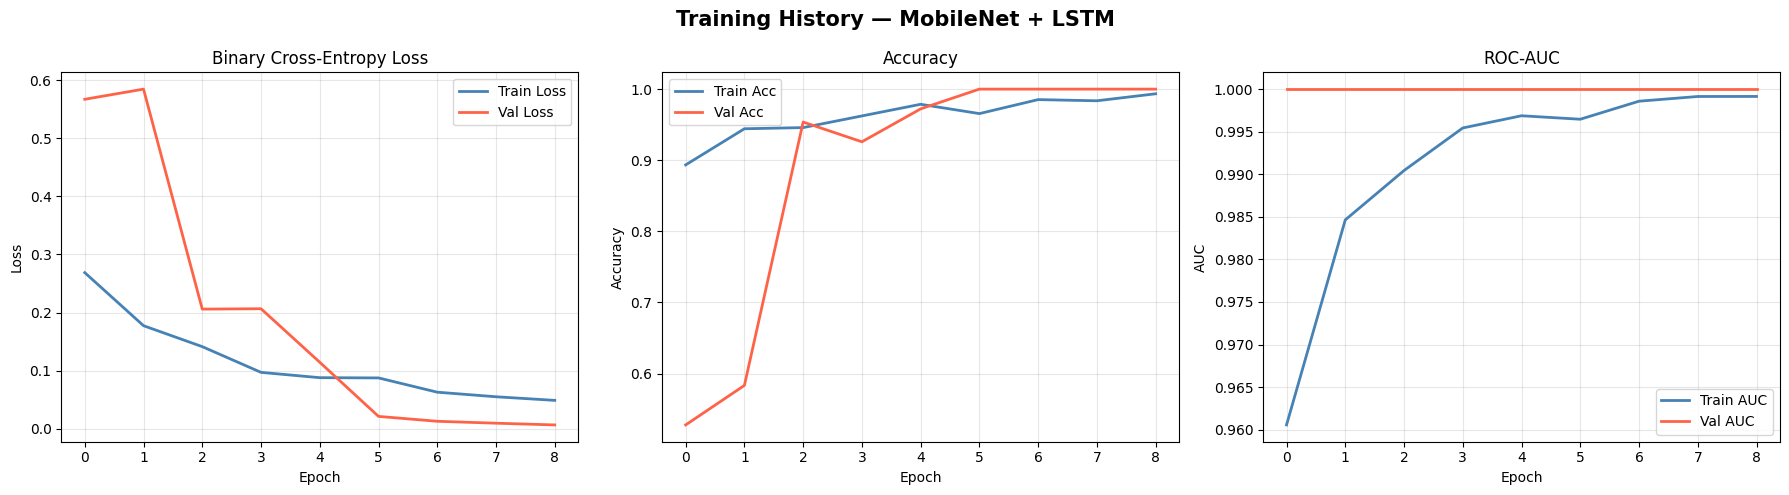

✅ Training history saved.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — MobileNet + LSTM', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato', lw=2)
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Acc', color='steelblue', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='tomato', lw=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(history.history['auc'], label='Train AUC', color='steelblue', lw=2)
axes[2].plot(history.history['val_auc'], label='Val AUC', color='tomato', lw=2)
axes[2].set_title('ROC-AUC')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved.")

---
## Cell 10 — Per-Frame Probability Inference on Test Videos

In [21]:
def predict_video_frame_probabilities(video_path, extractor, model,
                                       seq_length=SEQ_LENGTH, step=STEP_SIZE,
                                       threshold=THRESHOLD):
    """
    For a given video:
    1. Extract MobileNet features per frame
    2. Build sliding-window sequences
    3. Predict anomaly probability per sequence via LSTM+Sigmoid
    4. Map sequence probabilities back to individual frames
    5. Classify each frame as Normal / Abnormal using threshold

    Returns:
        frame_probs   : np.array (num_extracted_frames,) — probability per frame
        frame_labels  : np.array (num_extracted_frames,) — 0=Normal, 1=Abnormal
    """
    features = get_or_cache_features(video_path, extractor)   # (N, 1280)

    if len(features) < seq_length:
        print(f"  ⚠️  Video too short for sequence length {seq_length}")
        return np.array([]), np.array([])

    # Build sequences + track which frames are covered
    seqs       = []
    seq_starts = []
    for start in range(0, len(features) - seq_length + 1, step):
        seqs.append(features[start:start+seq_length])
        seq_starts.append(start)

    seqs_arr = np.array(seqs)                                  # (num_seq, SEQ_LENGTH, 1280)
    seq_probs = model.predict(seqs_arr, verbose=0).flatten()   # (num_seq,)

    # Map sequence probabilities → frame probabilities (average overlapping windows)
    frame_prob_accum  = np.zeros(len(features))
    frame_count       = np.zeros(len(features))

    for i, start in enumerate(seq_starts):
        frame_prob_accum[start:start+seq_length] += seq_probs[i]
        frame_count[start:start+seq_length]      += 1

    frame_count = np.maximum(frame_count, 1)   # avoid /0
    frame_probs  = frame_prob_accum / frame_count
    frame_labels = (frame_probs > threshold).astype(int)

    return frame_probs, frame_labels


print("✅ Inference function ready.")

✅ Inference function ready.


---
## Cell 11 — Run Inference on ALL Test Videos

In [22]:
print("=" * 60)
print("  Running inference on TEST videos...")
print("=" * 60)

test_results = {}    # video_name → {probs, labels, pct_abnormal}

for vname in tqdm(test_videos, desc="Testing"):
    vpath = os.path.join(TEST_VIDEO_DIR, vname)
    probs, labels = predict_video_frame_probabilities(
        vpath, mobilenet_extractor, lstm_model,
        threshold=THRESHOLD
    )

    if len(probs) == 0:
        continue

    pct_abnormal = 100.0 * labels.mean()
    test_results[vname] = {
        'probs'        : probs,
        'labels'       : labels,
        'pct_abnormal' : pct_abnormal,
        'mean_prob'    : probs.mean(),
        'max_prob'     : probs.max(),
        'verdict'      : 'ABNORMAL' if pct_abnormal > 10 else 'NORMAL'
    }


# ---- Summary Table ----
print("\n" + "=" * 75)
print(f"{'Video':<25} {'Mean Prob':>10} {'Max Prob':>10} {'% Abnormal':>12} {'Verdict':>10}")
print("=" * 75)
for vname, res in test_results.items():
    print(f"{vname:<25} {res['mean_prob']:>10.4f} {res['max_prob']:>10.4f} "
          f"{res['pct_abnormal']:>11.1f}% {res['verdict']:>10}")
print("=" * 75)

  Running inference on TEST videos...


Testing: 100%|██████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:01<00:00, 16.70it/s]


Video                      Mean Prob   Max Prob   % Abnormal    Verdict
01.avi                        0.0152     0.0170         0.0%     NORMAL
02.avi                        0.0157     0.0274         0.0%     NORMAL
03.avi                        0.0137     0.0170         0.0%     NORMAL
04.avi                        0.0146     0.0165         0.0%     NORMAL
05.avi                        0.0135     0.0149         0.0%     NORMAL
06.avi                        0.0129     0.0152         0.0%     NORMAL
07.avi                        0.0140     0.0231         0.0%     NORMAL
08.avi                        0.0130     0.0175         0.0%     NORMAL
09.avi                        0.0120     0.0147         0.0%     NORMAL
10.avi                        0.0135     0.0162         0.0%     NORMAL
11.avi                        0.0126     0.0156         0.0%     NORMAL
12.avi                        0.0148     0.0181         0.0%     NORMAL
13.avi                        0.0161     0.0181         0.0%   

---
## Cell 12 — Visualize Frame-Level Probability for Each Test Video

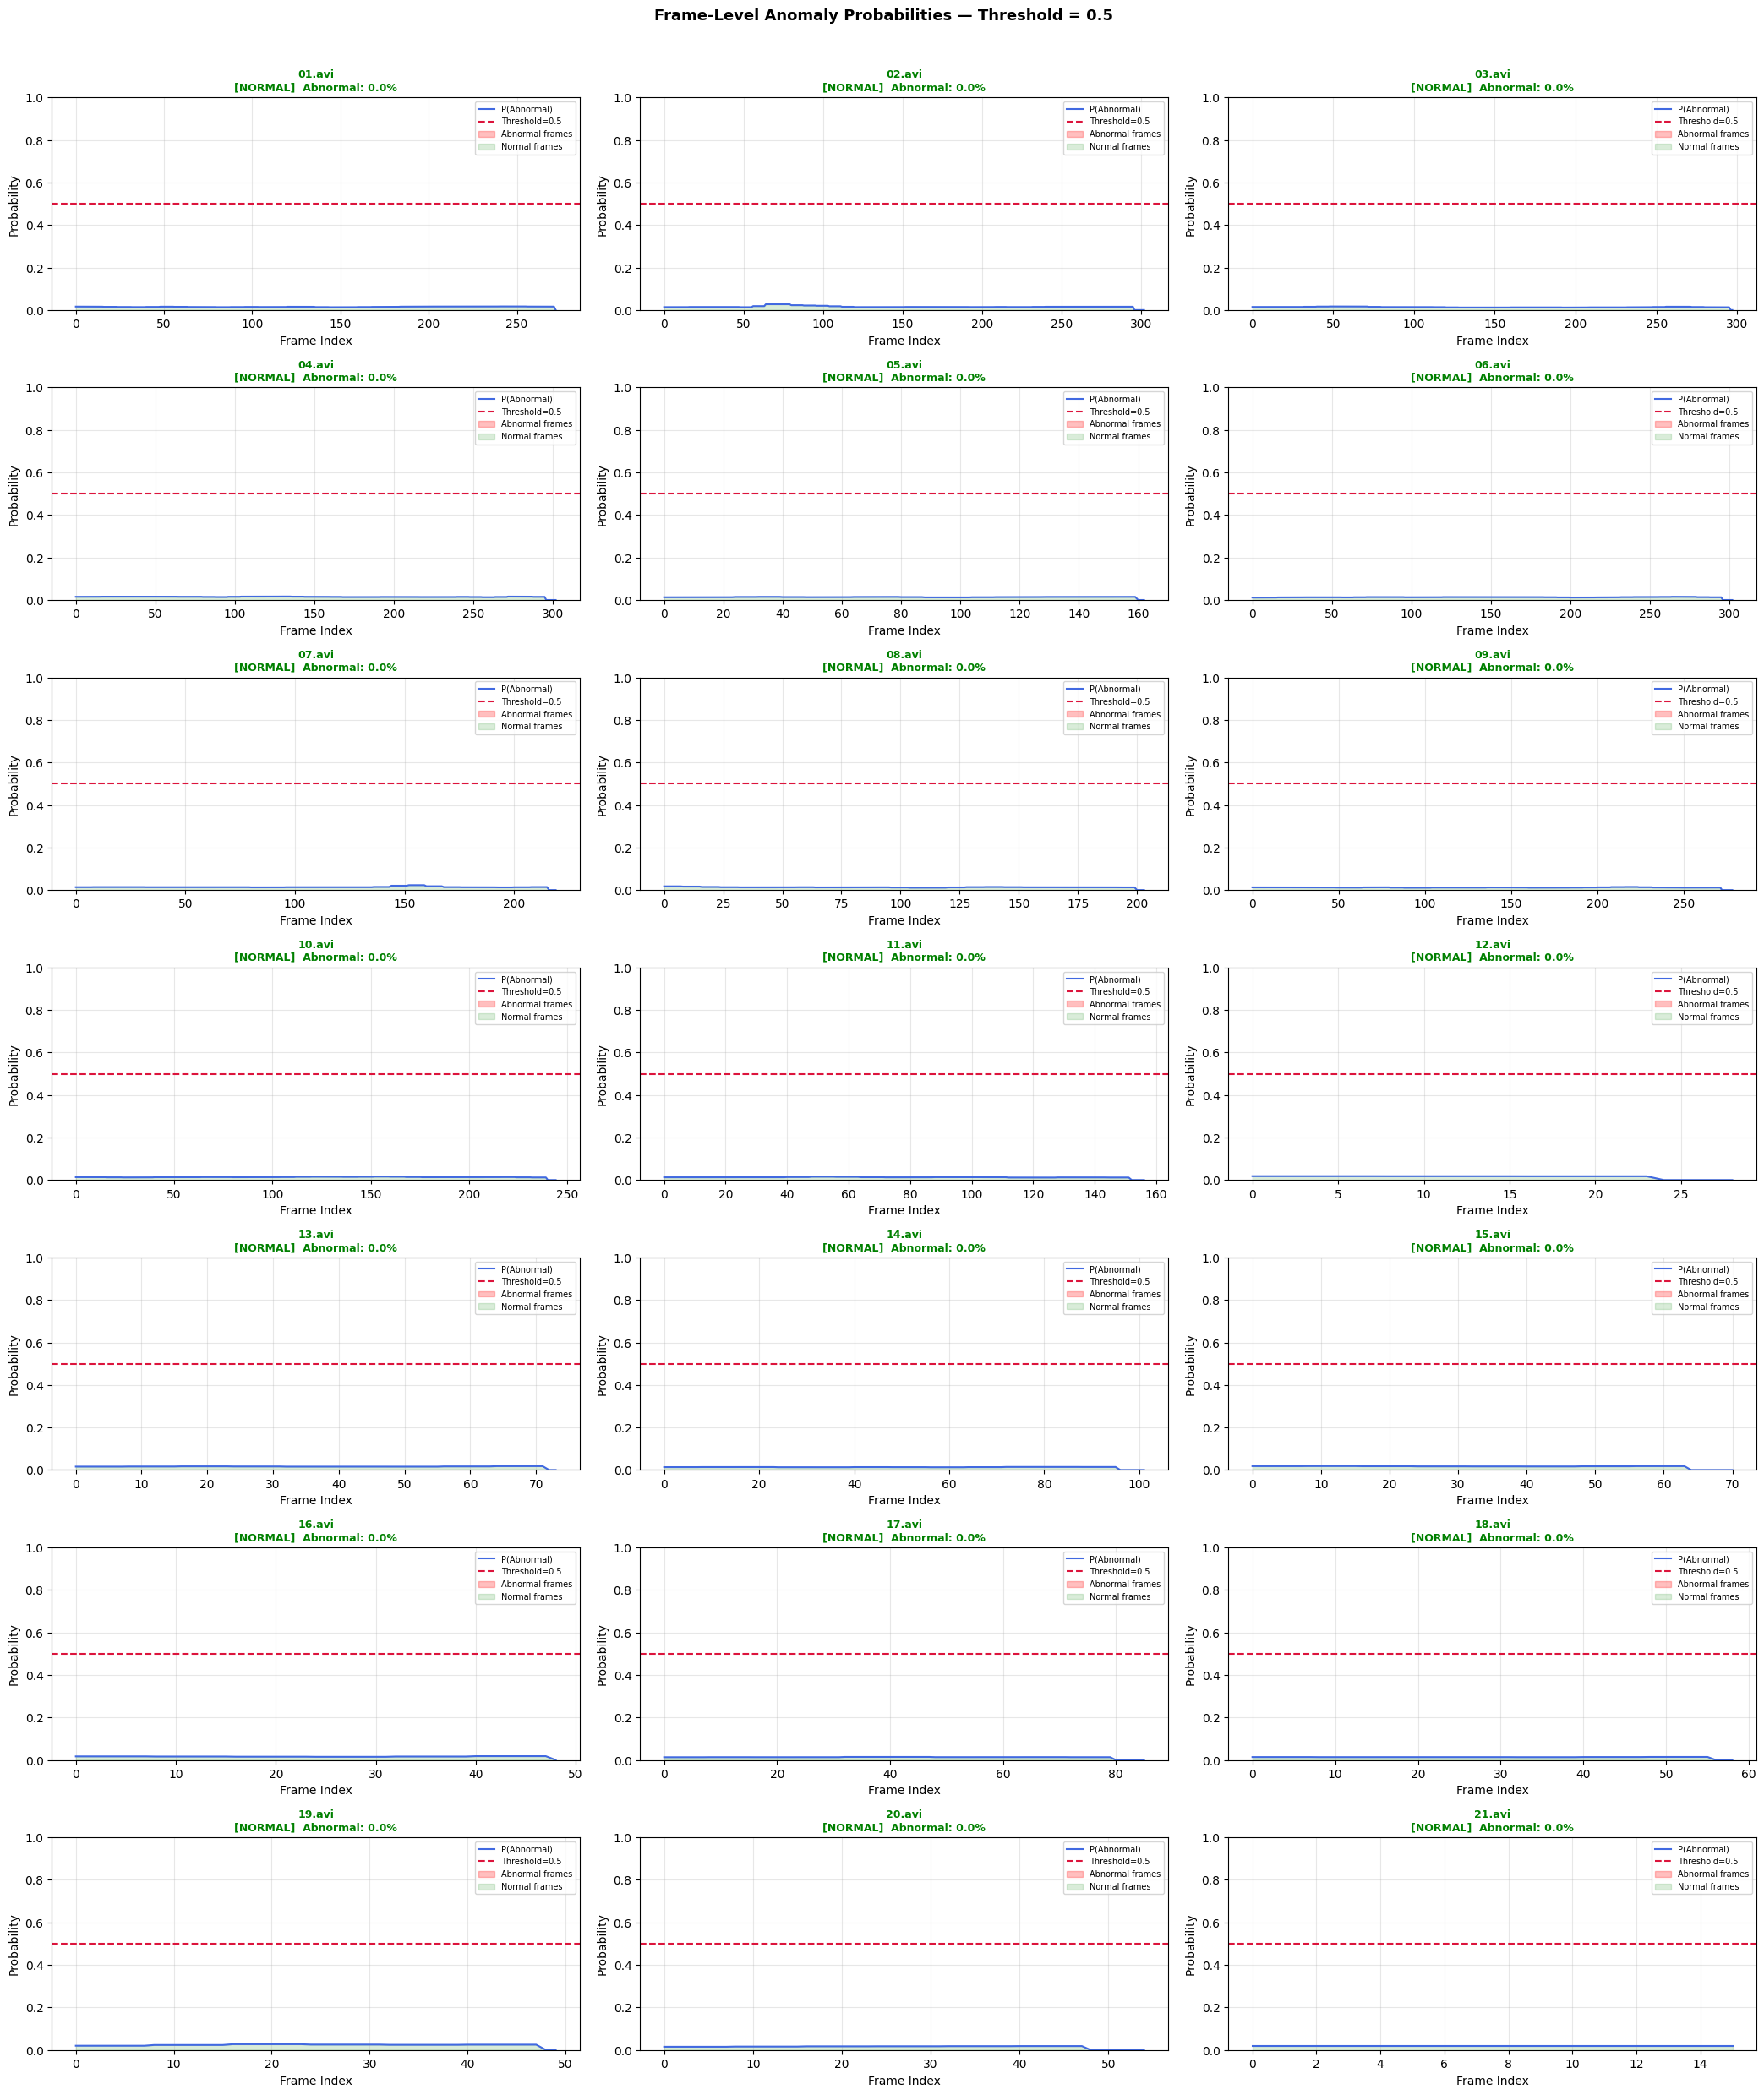

✅ Plot saved to: C:\Users\awati\Avenue_Dataset 3\Avenue Dataset\frame_level_probabilities.png


In [23]:
n_videos = len(test_results)
cols = 3
rows = (n_videos + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 3.5))
axes = axes.flatten() if n_videos > 1 else [axes]

for idx, (vname, res) in enumerate(test_results.items()):
    ax   = axes[idx]
    prob = res['probs']
    lbl  = res['labels']
    t    = np.arange(len(prob))

    # Background shading — red for abnormal regions
    in_abnormal = False
    start_abn   = 0
    for i in range(len(lbl)):
        if lbl[i] == 1 and not in_abnormal:
            start_abn   = i
            in_abnormal = True
        elif lbl[i] == 0 and in_abnormal:
            ax.axvspan(start_abn, i, alpha=0.15, color='red')
            in_abnormal = False
    if in_abnormal:
        ax.axvspan(start_abn, len(lbl), alpha=0.15, color='red')

    ax.plot(t, prob, color='royalblue', lw=1.5, label='P(Abnormal)')
    ax.axhline(THRESHOLD, color='crimson', lw=1.5, ls='--', label=f'Threshold={THRESHOLD}')
    ax.fill_between(t, 0, prob, where=(prob > THRESHOLD),
                    alpha=0.25, color='red', label='Abnormal frames')
    ax.fill_between(t, 0, prob, where=(prob <= THRESHOLD),
                    alpha=0.15, color='green', label='Normal frames')

    ax.set_title(f"{vname}\n[{res['verdict']}]  Abnormal: {res['pct_abnormal']:.1f}%",
                 fontsize=9, fontweight='bold',
                 color='red' if res['verdict']=='ABNORMAL' else 'green')
    ax.set_xlabel('Frame Index'); ax.set_ylabel('Probability')
    ax.set_ylim(0, 1); ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Frame-Level Anomaly Probabilities — Threshold = {THRESHOLD}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(BASE_DIR, 'frame_level_probabilities.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved to: {save_path}")

---
## Cell 13 — ROC Curve & AUC (Frame-Level)

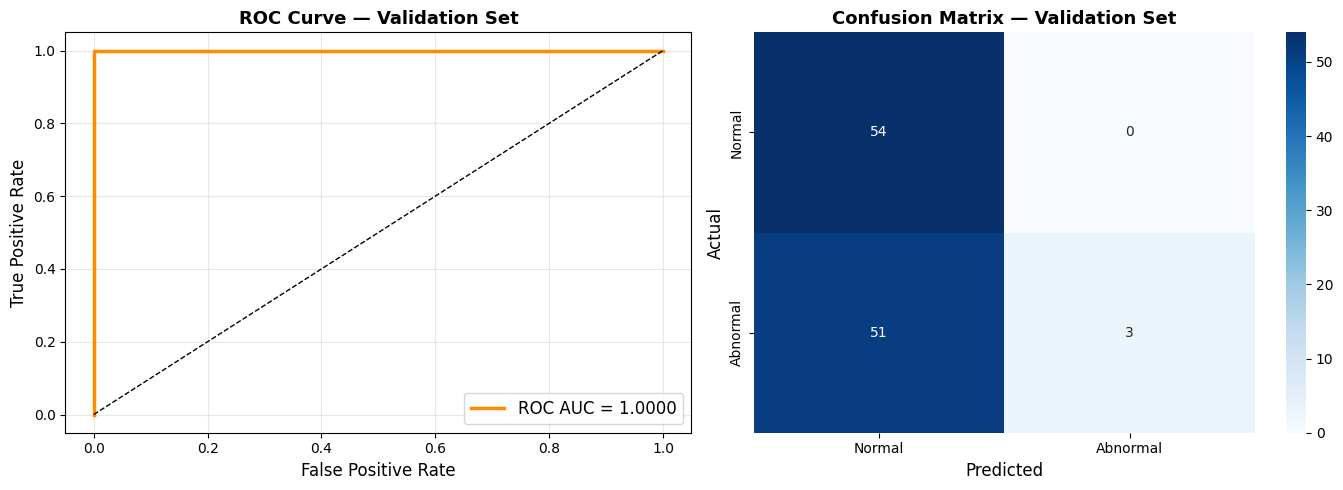


Classification Report (Validation Set):
              precision    recall  f1-score   support

      Normal       0.51      1.00      0.68        54
    Abnormal       1.00      0.06      0.11        54

    accuracy                           0.53       108
   macro avg       0.76      0.53      0.39       108
weighted avg       0.76      0.53      0.39       108

ROC AUC Score: 1.0000


In [24]:
# ============================================================
#  NOTE: If you have ground-truth XML/mat labels, load them here.
#  For demonstration, we compute ROC on the validation set.
# ============================================================

val_probs = lstm_model.predict(X_val, verbose=0).flatten()
val_preds = (val_probs > THRESHOLD).astype(int)

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_val, val_probs)
auc_score = roc_auc_score(y_val, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, lw=2.5, color='darkorange', label=f'ROC AUC = {auc_score:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Validation Set', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12); axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'roc_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=['Normal', 'Abnormal']))
print(f"ROC AUC Score: {auc_score:.4f}")

---
## Cell 14 — Threshold Sensitivity Analysis

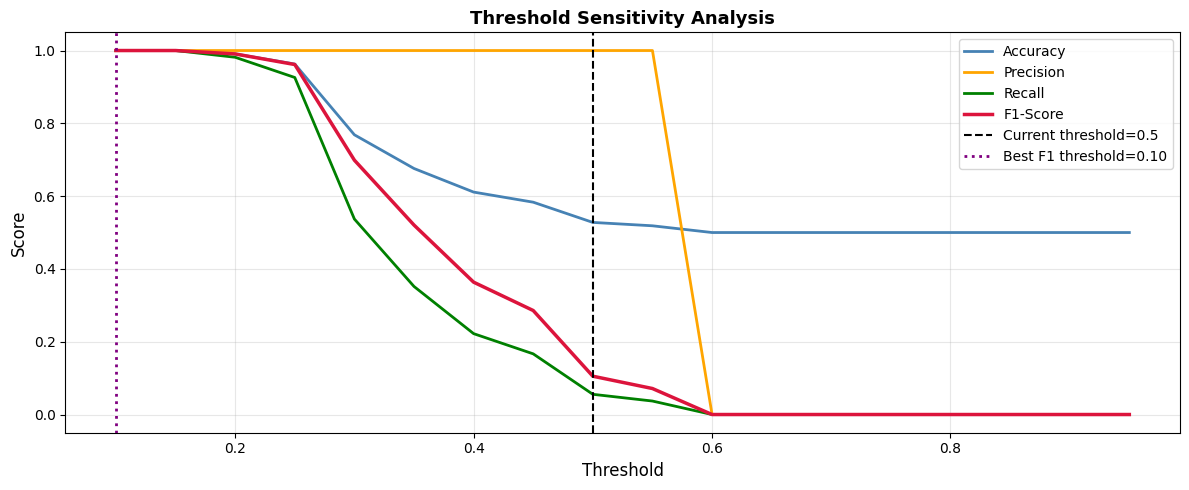

Best F1-Score threshold: 0.10  →  F1 = 1.0000
Current threshold=0.5  →  F1 = 0.1053


In [25]:
thresholds = np.arange(0.1, 1.0, 0.05)
accs, precs, recs, f1s = [], [], [], []

from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    preds = (val_probs > t).astype(int)
    accs.append(accuracy_score(y_val, preds))
    precs.append(precision_score(y_val, preds, zero_division=0))
    recs.append(recall_score(y_val, preds, zero_division=0))
    f1s.append(f1_score(y_val, preds, zero_division=0))

best_t_idx = np.argmax(f1s)
best_t     = thresholds[best_t_idx]

plt.figure(figsize=(12, 5))
plt.plot(thresholds, accs,  label='Accuracy',  lw=2, color='steelblue')
plt.plot(thresholds, precs, label='Precision', lw=2, color='orange')
plt.plot(thresholds, recs,  label='Recall',    lw=2, color='green')
plt.plot(thresholds, f1s,   label='F1-Score',  lw=2.5, color='crimson')
plt.axvline(THRESHOLD, color='black', ls='--', lw=1.5, label=f'Current threshold={THRESHOLD}')
plt.axvline(best_t,    color='purple', ls=':',  lw=2,   label=f'Best F1 threshold={best_t:.2f}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Threshold Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'threshold_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Best F1-Score threshold: {best_t:.2f}  →  F1 = {f1s[best_t_idx]:.4f}")
print(f"Current threshold={THRESHOLD}  →  F1 = {f1s[np.argmin(np.abs(thresholds - THRESHOLD))]:.4f}")

---
## Cell 15 — Visualize Sample Frames with Predictions

Most abnormal test video: 01.avi  (0.0% abnormal frames)


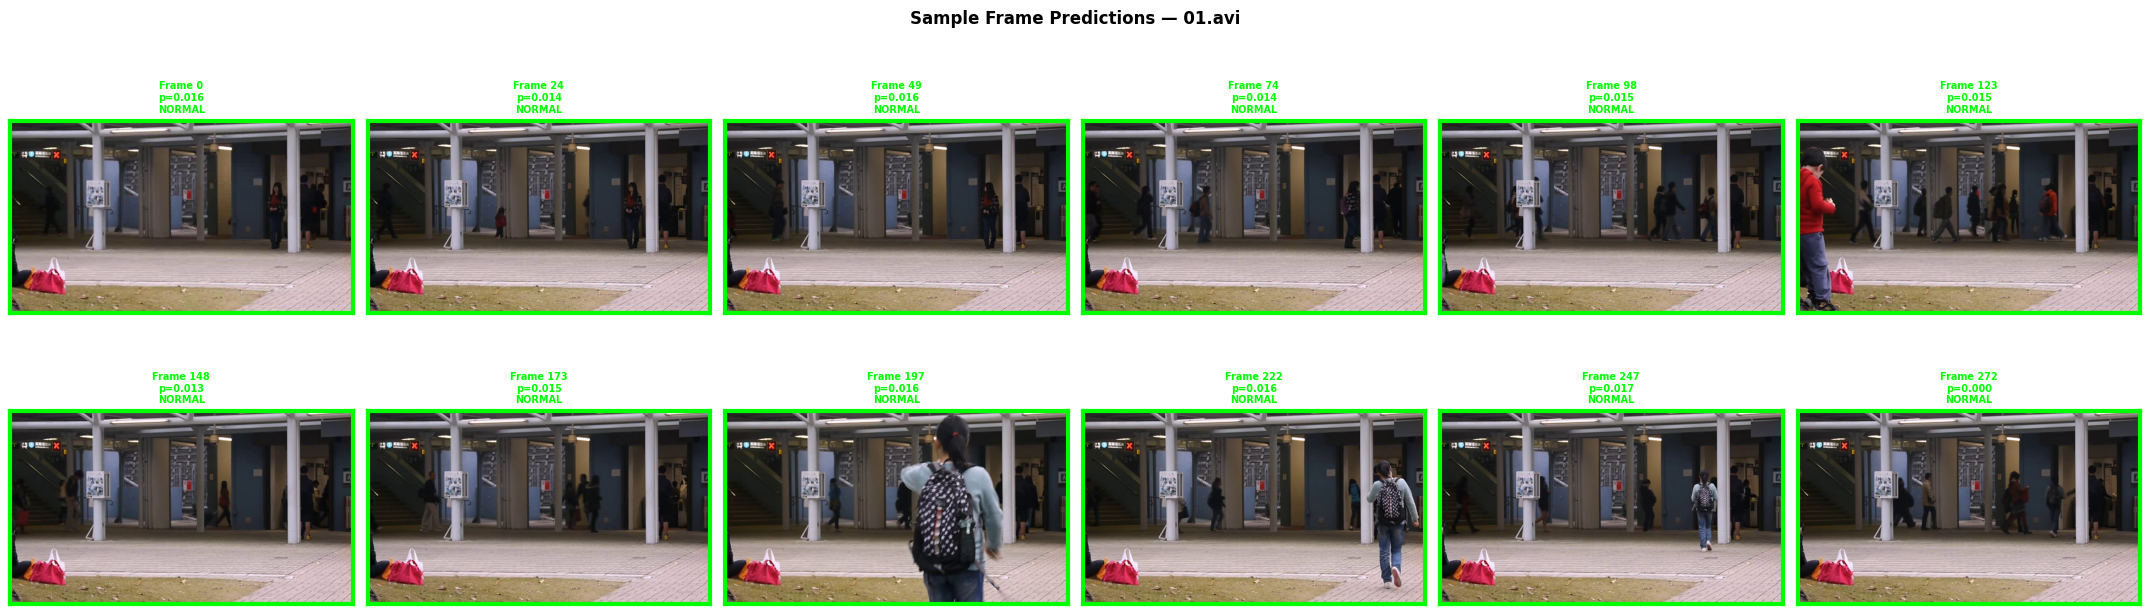

In [26]:
def visualize_video_predictions(video_path, probs, labels, n_samples=12,
                                 frame_skip=FRAME_SKIP, threshold=THRESHOLD):
    """
    Display sample frames from the video with their predicted
    anomaly probability and Normal/Abnormal label.
    """
    cap = cv2.VideoCapture(video_path)
    all_frames = []
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if idx % frame_skip == 0:
            all_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        idx += 1
    cap.release()

    n_frames = min(len(all_frames), len(probs))
    sample_indices = np.linspace(0, n_frames - 1, n_samples, dtype=int)

    fig, axes = plt.subplots(2, n_samples // 2, figsize=(n_samples * 1.8, 7))
    axes = axes.flatten()

    vname = os.path.basename(video_path)
    fig.suptitle(f'Sample Frame Predictions — {vname}', fontsize=12, fontweight='bold')

    for plot_i, frame_i in enumerate(sample_indices):
        ax = axes[plot_i]
        ax.imshow(all_frames[frame_i])

        p = probs[frame_i]
        verdict = 'ABNORMAL' if p > threshold else 'NORMAL'
        color   = 'red' if verdict == 'ABNORMAL' else 'lime'

        ax.set_title(f'Frame {frame_i}\np={p:.3f}\n{verdict}',
                     fontsize=7, color=color, fontweight='bold')

        # Border color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()


# Visualize first test video with most abnormal content
most_abnormal = max(test_results, key=lambda k: test_results[k]['pct_abnormal'])
print(f"Most abnormal test video: {most_abnormal}  ({test_results[most_abnormal]['pct_abnormal']:.1f}% abnormal frames)")

visualize_video_predictions(
    os.path.join(TEST_VIDEO_DIR, most_abnormal),
    test_results[most_abnormal]['probs'],
    test_results[most_abnormal]['labels'],
    n_samples=12
)

---
## Cell 16 — Summary Dashboard


  COMPLETE INFERENCE SUMMARY — ALL TEST VIDEOS
 Video  Total Frames  Abnormal Frames  Normal Frames  % Abnormal  Mean Prob  Max Prob Verdict
01.avi           273                0            273         0.0     0.0152    0.0170  NORMAL
02.avi           303                0            303         0.0     0.0157    0.0274  NORMAL
03.avi           298                0            298         0.0     0.0137    0.0170  NORMAL
04.avi           303                0            303         0.0     0.0146    0.0165  NORMAL
05.avi           163                0            163         0.0     0.0135    0.0149  NORMAL
06.avi           303                0            303         0.0     0.0129    0.0152  NORMAL
07.avi           220                0            220         0.0     0.0140    0.0231  NORMAL
08.avi           204                0            204         0.0     0.0130    0.0175  NORMAL
09.avi           279                0            279         0.0     0.0120    0.0147  NORMAL
10.avi      

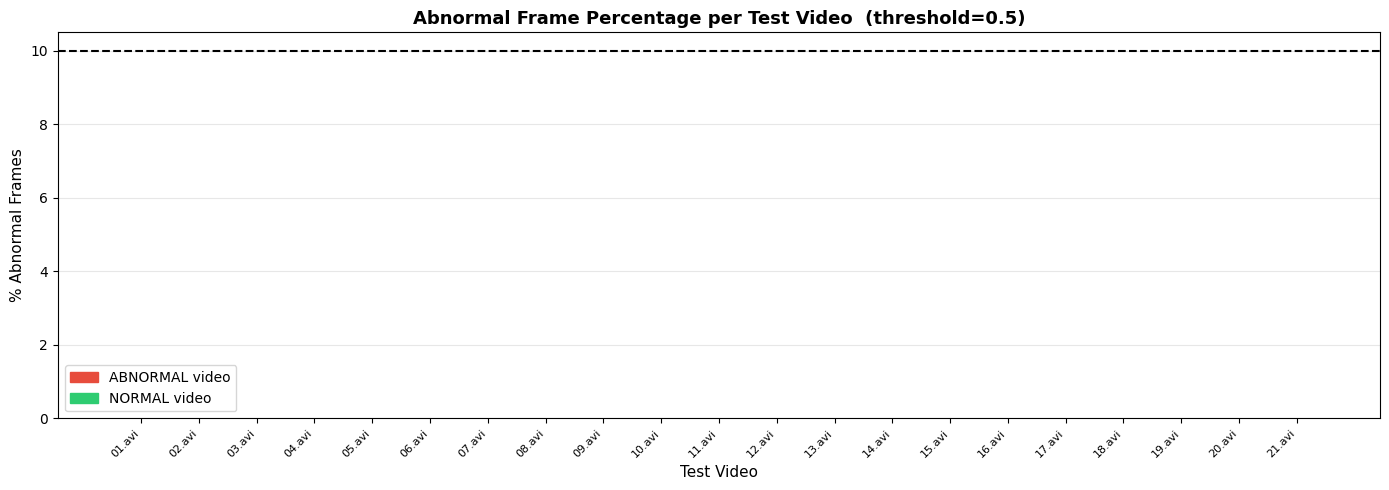

✅ Summary chart saved.


In [27]:
# ---- Aggregate summary across all test videos ----
summary_df = pd.DataFrame([
    {
        'Video'         : vname,
        'Total Frames'  : len(res['probs']),
        'Abnormal Frames': res['labels'].sum(),
        'Normal Frames' : (res['labels'] == 0).sum(),
        '% Abnormal'    : round(res['pct_abnormal'], 2),
        'Mean Prob'     : round(float(res['mean_prob']), 4),
        'Max Prob'      : round(float(res['max_prob']), 4),
        'Verdict'       : res['verdict']
    }
    for vname, res in test_results.items()
])

print("\n" + "=" * 80)
print("  COMPLETE INFERENCE SUMMARY — ALL TEST VIDEOS")
print("=" * 80)
print(summary_df.to_string(index=False))

print(f"\n📊 Total test videos    : {len(summary_df)}")
print(f"   Detected as ABNORMAL : {(summary_df['Verdict']=='ABNORMAL').sum()}")
print(f"   Detected as NORMAL   : {(summary_df['Verdict']=='NORMAL').sum()}")
print(f"   Overall % abnormal   : {summary_df['% Abnormal'].mean():.2f}%")

# Save summary
csv_path = os.path.join(BASE_DIR, 'test_inference_summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f"\n✅ Summary saved to: {csv_path}")


# ---- Bar chart ----
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if v == 'ABNORMAL' else '#2ecc71' for v in summary_df['Verdict']]
bars   = ax.bar(summary_df['Video'], summary_df['% Abnormal'], color=colors, edgecolor='white', lw=0.8)
ax.axhline(10, color='black', ls='--', lw=1.5, label='Decision boundary (10%)')
ax.set_xlabel('Test Video', fontsize=11)
ax.set_ylabel('% Abnormal Frames', fontsize=11)
ax.set_title(f'Abnormal Frame Percentage per Test Video  (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(summary_df['Video'], rotation=45, ha='right', fontsize=8)
red_patch   = mpatches.Patch(color='#e74c3c', label='ABNORMAL video')
green_patch = mpatches.Patch(color='#2ecc71', label='NORMAL video')
ax.legend(handles=[red_patch, green_patch], fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'abnormal_summary_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary chart saved.")

---
## Cell 17 — Save & Load Model (Reuse Without Retraining)

In [28]:
# ---- Save full model (.keras format — required for TF/Keras 2.12+) ----
lstm_model.save(MODEL_PATH)   # MODEL_PATH ends in .keras
print(f"✅ Model saved: {MODEL_PATH}")

# ---- Load model in a future session ----
# from tensorflow.keras.models import load_model
# lstm_model = load_model(MODEL_PATH)  # pass the .keras path
# print("✅ Model loaded.")

print("\n" + "=" * 60)
print("  PIPELINE COMPLETE")
print("=" * 60)
print(f"  MobileNetV2   → Feature extraction (1280-dim per frame)")
print(f"  LSTM (2 layer)→ Temporal sequence modeling")
print(f"  Sigmoid       → Anomaly probability [0, 1]")
print(f"  Threshold     → {THRESHOLD}  (prob > threshold = ABNORMAL)")
print("=" * 60)

✅ Model saved: C:\Users\awati\Avenue_Dataset 3\Avenue Dataset\mobilenet_lstm_abnormal.keras

  PIPELINE COMPLETE
  MobileNetV2   → Feature extraction (1280-dim per frame)
  LSTM (2 layer)→ Temporal sequence modeling
  Sigmoid       → Anomaly probability [0, 1]
  Threshold     → 0.5  (prob > threshold = ABNORMAL)
